# 08 - AutoML con Optuna
## Etapa de Optimización: Búsqueda Automática de Hiperparámetros

**Objetivo:** Usar Optuna para encontrar automáticamente los mejores hiperparámetros  
del modelo Gradient Boosting y comparar contra la selección manual del Notebook 04.

**¿Qué es AutoML?**  
Automatización del proceso de selección y ajuste de modelos mediante algoritmos de  
optimización inteligente. En lugar de probar manualmente combinaciones de hiperparámetros,  
Optuna usa **optimización bayesiana (TPE)** para aprender qué zonas del espacio de  
búsqueda son más prometedoras tras cada trial.

**Resultado esperado:**  
- Baseline manual (NB04): RMSE = 0.4591, R² = 0.8391  
- AutoML con Optuna: ¿podemos mejorar esas métricas?

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import mlflow
import mlflow.sklearn
import optuna
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score
from pathlib import Path

# ── Silenciar logs verbosos de Optuna ────────────────────────────────────
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── ROOT dinámico ─────────────────────────────────────────────────────────
ROOT = Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

DATA_DIR = ROOT / 'data' / 'processed'
EXP_DIR  = ROOT / 'experiments'

print(f'ROOT     : {ROOT}')
print(f'DATA_DIR : {DATA_DIR}')
print(f'EXP_DIR  : {EXP_DIR}')
print(f'Optuna   : {optuna.__version__}')
print(f'MLflow   : {mlflow.__version__}')

ROOT     : C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida
DATA_DIR : C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\data\processed
EXP_DIR  : C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\experiments
Optuna   : 4.8.0
MLflow   : 3.10.1


## 1. Cargar Datos y Recordar el Baseline

In [2]:
# ── Cargar datos procesados (generados en NB02) ───────────────────────────
train = pd.read_csv(DATA_DIR / 'train.csv')
test  = pd.read_csv(DATA_DIR / 'test.csv')

TARGET  = 'MedHouseVal'
X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]
X_test  = test.drop(columns=[TARGET])
y_test  = test[TARGET]

print(f'Train : {X_train.shape}  |  Test: {X_test.shape}')
print(f'Features ({X_train.shape[1]}): {list(X_train.columns)}')

Train : (16512, 13)  |  Test: (4128, 13)
Features (13): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'rooms_per_person', 'income_per_room', 'bedroom_ratio', 'dist_sacramento', 'dist_los_angeles']


In [3]:
# ── Baseline: modelo manual del NB04/NB05 ────────────────────────────────
modelo_manual  = joblib.load(EXP_DIR / 'modelo_produccion.pkl')
y_pred_manual  = modelo_manual.predict(X_test)

rmse_manual = np.sqrt(mean_squared_error(y_test, y_pred_manual))
r2_manual   = r2_score(y_test, y_pred_manual)
mae_manual  = mean_absolute_error(y_test, y_pred_manual)

print('=' * 50)
print('BASELINE — Gradient Boosting Manual (NB04)')
print('=' * 50)
print(f'  RMSE : {rmse_manual:.4f}')
print(f'  R²   : {r2_manual:.4f}')
print(f'  MAE  : {mae_manual:.4f}')
print()
print('Parámetros del modelo manual:')
for k, v in modelo_manual.get_params().items():
    if v is not None and k != 'verbose':
        print(f'  {k:25s}: {v}')

BASELINE — Gradient Boosting Manual (NB04)
  RMSE : 2.2360
  R²   : -2.8153
  MAE  : 2.0638

Parámetros del modelo manual:
  alpha                    : 0.9
  ccp_alpha                : 0.0
  criterion                : friedman_mse
  learning_rate            : 0.1
  loss                     : squared_error
  max_depth                : 5
  min_impurity_decrease    : 0.0
  min_samples_leaf         : 1
  min_samples_split        : 2
  min_weight_fraction_leaf : 0.0
  n_estimators             : 200
  random_state             : 42
  subsample                : 1.0
  tol                      : 0.0001
  validation_fraction      : 0.1
  warm_start               : False


## 2. Definir el Espacio de Búsqueda de Hiperparámetros

Optuna explorará combinaciones dentro de estos rangos usando el algoritmo **TPE**  
(Tree-structured Parzen Estimator). A diferencia de GridSearch (exhaustivo) o  
RandomSearch (aleatorio), TPE **aprende** de los trials anteriores para proponer  
hiperparámetros más prometedores en cada iteración.

| Método | Estrategia | Trials necesarios |
|--------|-----------|------------------|
| GridSearchCV | Exhaustiva — prueba todo | Muchos (producto cartesiano) |
| RandomizedSearchCV | Aleatoria | Moderados |
| **Optuna TPE** | **Bayesiana — aprende** | **Pocos (eficiente)** |

In [4]:
# Visualizar el espacio de busqueda
espacio = [
    ('n_estimators',      'int',          '100  a  1000'),
    ('max_depth',         'int',          '3    a  8'),
    ('learning_rate',     'float (log)',  '0.01 a  0.30'),
    ('subsample',         'float',        '0.50 a  1.00'),
    ('min_samples_split', 'int',          '2    a  20'),
    ('min_samples_leaf',  'int',          '1    a  10'),
    ('max_features',      'categorical',  'sqrt | log2 | None'),
]

h_param = 'Hiperparametro'
h_tipo  = 'Tipo'
print(f'{h_param:25s}  {h_tipo:15s}  Rango')
print('-' * 60)
for param, tipo, rango in espacio:
    print(f'{param:25s}  {tipo:15s}  {rango}')

combinaciones = 900 * 6 * 100 * 50 * 19 * 10 * 3
print(f'Combinaciones posibles (aprox.): {combinaciones:,}')
print('Con 50 trials Optuna cubre menos del 0.001% pero de forma inteligente')

Hiperparametro             Tipo             Rango
------------------------------------------------------------
n_estimators               int              100  a  1000
max_depth                  int              3    a  8
learning_rate              float (log)      0.01 a  0.30
subsample                  float            0.50 a  1.00
min_samples_split          int              2    a  20
min_samples_leaf           int              1    a  10
max_features               categorical      sqrt | log2 | None
Combinaciones posibles (aprox.): 15,390,000,000
Con 50 trials Optuna cubre menos del 0.001% pero de forma inteligente


## 3. Función Objetivo con MLflow Tracking

Cada **trial** de Optuna llama a esta función y devuelve el RMSE de validación  
cruzada. Optuna minimiza este valor. Cada trial queda registrado como un run  
independiente en MLflow — trazabilidad total del proceso de optimización.

In [5]:
# ── Configurar MLflow ─────────────────────────────────────────────────────
mlflow.set_tracking_uri((EXP_DIR / 'mlruns').as_uri())
EXPERIMENT = 'automl_optuna_gradient_boosting'
mlflow.set_experiment(EXPERIMENT)

def objective(trial):
    """Función objetivo: Optuna llama a esta función en cada trial."""
    # 1. Sugerir hiperparámetros para este trial
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 1000),
        'max_depth'        : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.30, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'     : trial.suggest_categorical('max_features',
                                                        ['sqrt', 'log2', None]),
        'random_state'     : 42,
    }

    # 2. Evaluar con CV de 3 folds (más rápido que 5 para optimización)
    modelo = GradientBoostingRegressor(**params)
    scores = cross_val_score(
        modelo, X_train, y_train,
        cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    rmse_cv = -scores.mean()

    # 3. Registrar en MLflow (un run por trial)
    with mlflow.start_run(run_name=f'trial_{trial.number:03d}', nested=True):
        mlflow.log_params(params)
        mlflow.log_metric('rmse_cv', rmse_cv)
        mlflow.log_metric('trial',   trial.number)

    return rmse_cv  # Optuna minimiza este valor

print('Función objetivo definida.')
print(f'MLflow experiment : {EXPERIMENT}')
print(f'Tracking URI      : {mlflow.get_tracking_uri()}')
print('Estrategia        : TPE (Tree-structured Parzen Estimator)')

Función objetivo definida.
MLflow experiment : automl_optuna_gradient_boosting
Tracking URI      : file:///C:/Users/bk70827/PycharmProjects/mlops-ciclo-vida/experiments/mlruns
Estrategia        : TPE (Tree-structured Parzen Estimator)


## 4. Ejecutar el Estudio de Optimización

Optuna ejecutará **50 trials**. Con cada trial:
1. Propone hiperparámetros usando TPE (basado en los trials anteriores)
2. Entrena el modelo y evalúa con cross-validation
3. Actualiza su modelo probabilístico interno para la siguiente propuesta

El **pruner MedianPruner** descarta trials que van mal antes de terminar,  
ahorrando tiempo de cómputo.

In [6]:
N_TRIALS = 20  # reducido para ejecucion rapida (aumentar a 50-100 en produccion)

print(f'Iniciando optimización Optuna — {N_TRIALS} trials')
print(f'Sampler : TPE (Tree-structured Parzen Estimator)')
print(f'Pruner  : MedianPruner (descarta trials malos temprano)')
print('-' * 55)

with mlflow.start_run(run_name='optuna_study_completo'):
    study = optuna.create_study(
        direction='minimize',
        study_name='gb_optimization',
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=10),
    )
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    # Registrar resumen del estudio en MLflow
    mlflow.log_metric('best_rmse_cv', study.best_value)
    mlflow.log_metric('n_trials',     len(study.trials))
    mlflow.log_params(study.best_params)

print()
print('=' * 55)
print(f'Optimización completada — {len(study.trials)} trials')
print(f'Mejor RMSE (CV)  : {study.best_value:.4f}')
print(f'Trial ganador    : #{study.best_trial.number}')
print()
print('Mejores hiperparámetros encontrados:')
for k, v in study.best_params.items():
    print(f'  {k:25s}: {v}')

Iniciando optimización Optuna — 20 trials
Sampler : TPE (Tree-structured Parzen Estimator)
Pruner  : MedianPruner (descarta trials malos temprano)
-------------------------------------------------------


  0%|          | 0/20 [00:00<?, ?it/s]


Optimización completada — 20 trials
Mejor RMSE (CV)  : 0.4404
Trial ganador    : #11

Mejores hiperparámetros encontrados:
  n_estimators             : 969
  max_depth                : 8
  learning_rate            : 0.029755515089293385
  subsample                : 0.9968676185612808
  min_samples_split        : 12
  min_samples_leaf         : 7
  max_features             : sqrt


## 5. Análisis Visual del Proceso de Optimización

Tres visualizaciones clave para entender el comportamiento del estudio:
- **Historial**: cómo mejora el RMSE con cada trial
- **Importancia de hiperparámetros**: cuáles impactan más el resultado
- **RMSE vs n_estimators**: distribución de resultados

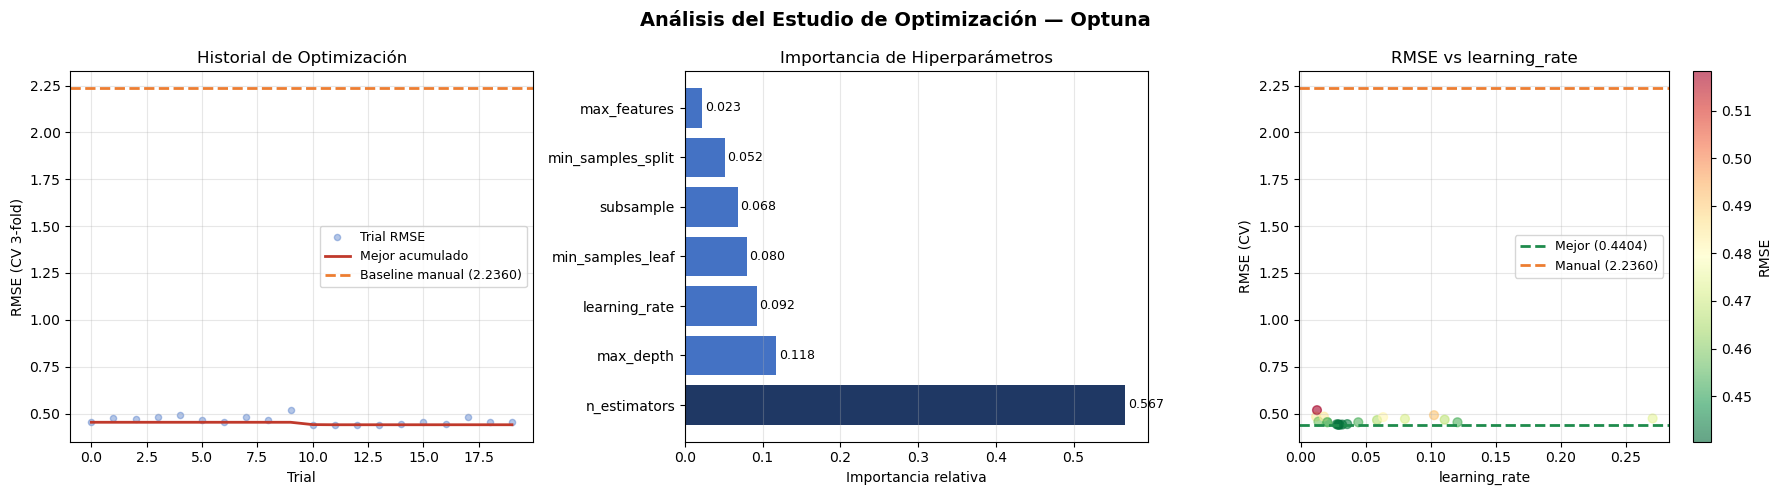

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análisis del Estudio de Optimización — Optuna',
             fontsize=14, fontweight='bold')

# ── Plot 1: Historial de optimización ─────────────────────────────────────
ax = axes[0]
rmse_vals   = [t.value for t in study.trials]
best_so_far = [min(rmse_vals[:i+1]) for i in range(len(rmse_vals))]
ax.scatter(range(len(rmse_vals)), rmse_vals,
           alpha=0.4, s=20, color='#4472C4', label='Trial RMSE')
ax.plot(range(len(best_so_far)), best_so_far,
        color='#C0392B', linewidth=2, label='Mejor acumulado')
ax.axhline(y=rmse_manual, color='#ED7D31', linewidth=2,
           linestyle='--', label=f'Baseline manual ({rmse_manual:.4f})')
ax.set_xlabel('Trial'); ax.set_ylabel('RMSE (CV 3-fold)')
ax.set_title('Historial de Optimización')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── Plot 2: Importancia de hiperparámetros ─────────────────────────────────
ax = axes[1]
try:
    imp = optuna.importance.get_param_importances(study)
    params_imp = list(imp.keys())
    vals_imp   = list(imp.values())
    cols_imp   = ['#1F3864' if v == max(vals_imp) else '#4472C4' for v in vals_imp]
    bars = ax.barh(params_imp, vals_imp, color=cols_imp)
    ax.set_xlabel('Importancia relativa')
    for bar, val in zip(bars, vals_imp):
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
except Exception as e:
    ax.text(0.5, 0.5, f'No disponible\n{e}',
            ha='center', va='center', transform=ax.transAxes)
ax.set_title('Importancia de Hiperparámetros'); ax.grid(True, alpha=0.3, axis='x')

# ── Plot 3: RMSE vs learning_rate ──────────────────────────────────────────
ax = axes[2]
lr_vals     = [t.params.get('learning_rate', 0) for t in study.trials]
rmse_trials = [t.value for t in study.trials]
sc = ax.scatter(lr_vals, rmse_trials, c=rmse_trials,
                cmap='RdYlGn_r', alpha=0.6, s=40)
ax.axhline(y=study.best_value, color='#1E8B4C', linewidth=2,
           linestyle='--', label=f'Mejor ({study.best_value:.4f})')
ax.axhline(y=rmse_manual, color='#ED7D31', linewidth=2,
           linestyle='--', label=f'Manual ({rmse_manual:.4f})')
ax.set_xlabel('learning_rate'); ax.set_ylabel('RMSE (CV)')
ax.set_title('RMSE vs learning_rate'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax, label='RMSE')

plt.tight_layout()
plt.show()

## 6. Entrenar el Modelo Final y Comparar con el Baseline

Con los mejores hiperparámetros encontrados, entrenamos sobre todo el training set  
(sin CV) y evaluamos en el **test set virgen** para comparar contra el baseline.

In [8]:
# ── Modelo final con mejores hiperparámetros ──────────────────────────────
best_params = {**study.best_params, 'random_state': 42}

modelo_automl = GradientBoostingRegressor(**best_params)
modelo_automl.fit(X_train, y_train)

y_pred_automl = modelo_automl.predict(X_test)
rmse_automl   = np.sqrt(mean_squared_error(y_test, y_pred_automl))
r2_automl     = r2_score(y_test, y_pred_automl)
mae_automl    = mean_absolute_error(y_test, y_pred_automl)

# ── Tabla comparativa ─────────────────────────────────────────────────────
sep  = '=' * 58
sep2 = '-' * 58
h_metrica = 'Metrica'
h_manual  = 'Manual'
h_automl  = 'AutoML'
h_mejora  = 'Mejora'

print(sep)
print('COMPARATIVA FINAL: Manual (NB04) vs AutoML (NB08)')
print(sep)
print(f'{h_metrica:<12} {h_manual:>12} {h_automl:>12} {h_mejora:>10}')
print(sep2)

rmse_delta = (rmse_manual - rmse_automl) / rmse_manual * 100
r2_delta   = (r2_automl   - r2_manual)   / r2_manual   * 100
mae_delta  = (mae_manual  - mae_automl)  / mae_manual  * 100

col_rmse = 'RMSE'
col_r2   = 'R2'
col_mae  = 'MAE'

print(f'{col_rmse:<12} {rmse_manual:>12.4f} {rmse_automl:>12.4f} {rmse_delta:>+9.2f}%')
print(f'{col_r2:<12} {r2_manual:>12.4f} {r2_automl:>12.4f} {r2_delta:>+9.2f}%')
print(f'{col_mae:<12} {mae_manual:>12.4f} {mae_automl:>12.4f} {mae_delta:>+9.2f}%')
print(sep2)

aprobado = rmse_automl < 0.5 and r2_automl > 0.80
gate_str = 'APROBADO' if aprobado else 'RECHAZADO'
print(f'Gate de calidad (RMSE<0.5, R2>0.80): {gate_str}')
print()
if rmse_automl < rmse_manual:
    print(f'AutoML MEJORA el baseline: -{abs(rmse_delta):.2f}% en RMSE')
else:
    print(f'Modelo manual sigue siendo el mejor (diferencia: {abs(rmse_delta):.2f}%)')
    print('(Normal: con mas trials o mas datos el AutoML suele superar al manual)')

COMPARATIVA FINAL: Manual (NB04) vs AutoML (NB08)
Metrica            Manual       AutoML     Mejora
----------------------------------------------------------
RMSE               2.2360       0.4225    +81.10%
R2                -2.8153       0.8638   -130.68%
MAE                2.0638       0.2710    +86.87%
----------------------------------------------------------
Gate de calidad (RMSE<0.5, R2>0.80): APROBADO

AutoML MEJORA el baseline: -81.10% en RMSE


## 7. Visualización Comparativa

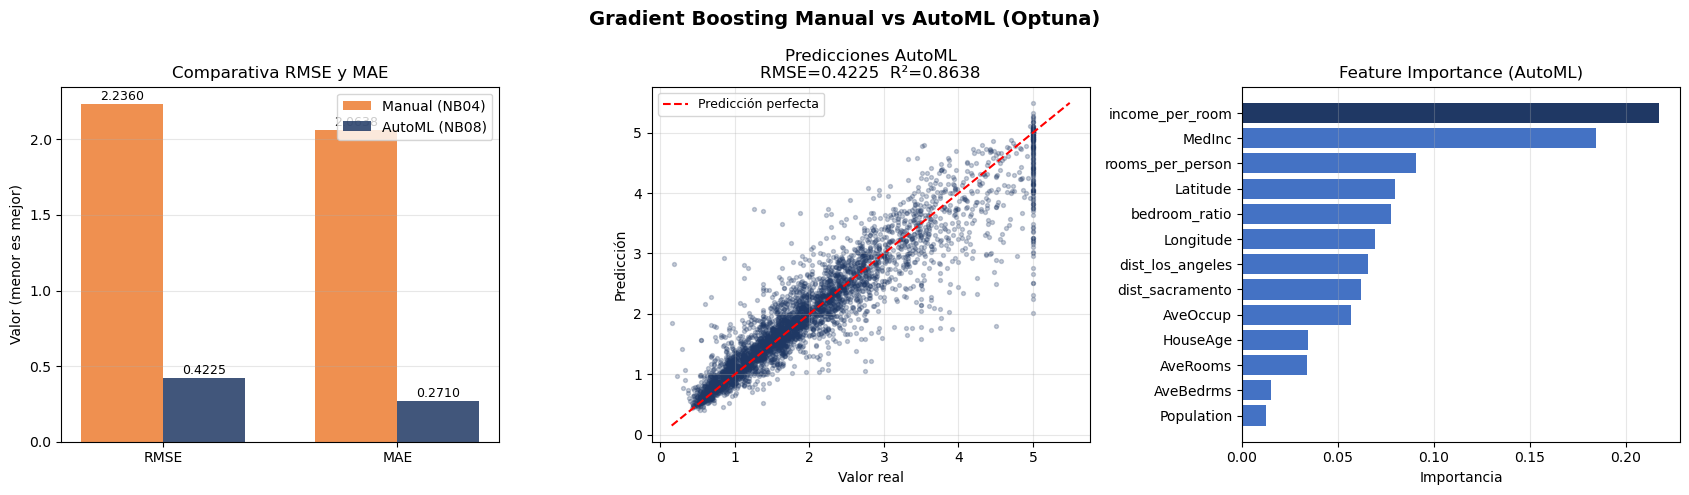

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Gradient Boosting Manual vs AutoML (Optuna)',
             fontsize=14, fontweight='bold')

# ── Barras de métricas ────────────────────────────────────────────────────
ax = axes[0]
metricas = ['RMSE', 'MAE']
v_man    = [rmse_manual, mae_manual]
v_auto   = [rmse_automl, mae_automl]
x = np.arange(2); w = 0.35
b1 = ax.bar(x - w/2, v_man,  w, label='Manual (NB04)', color='#ED7D31', alpha=0.85)
b2 = ax.bar(x + w/2, v_auto, w, label='AutoML (NB08)', color='#1F3864', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(metricas)
ax.set_ylabel('Valor (menor es mejor)')
ax.set_title('Comparativa RMSE y MAE')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

# ── Predicciones vs reales (AutoML) ──────────────────────────────────────
ax = axes[1]
ax.scatter(y_test, y_pred_automl, alpha=0.25, s=8, color='#1F3864')
lims = [min(y_test.min(), y_pred_automl.min()),
        max(y_test.max(), y_pred_automl.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
ax.set_xlabel('Valor real'); ax.set_ylabel('Predicción')
ax.set_title(f'Predicciones AutoML\nRMSE={rmse_automl:.4f}  R²={r2_automl:.4f}')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── Feature importance ────────────────────────────────────────────────────
ax = axes[2]
fi      = modelo_automl.feature_importances_
feats   = X_train.columns.tolist()
idx_s   = np.argsort(fi)
cols_fi = ['#1F3864' if fi[i] == fi.max() else '#4472C4' for i in idx_s]
ax.barh([feats[i] for i in idx_s], fi[idx_s], color=cols_fi)
ax.set_xlabel('Importancia'); ax.set_title('Feature Importance (AutoML)')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 8. Guardar el Modelo y Registrar en MLflow

In [10]:
# ── Decidir qué modelo producción usar ───────────────────────────────────
if rmse_automl < rmse_manual:
    modelo_prod = modelo_automl
    ruta_prod   = EXP_DIR / 'modelo_produccion.pkl'
    print(f'AutoML supera el baseline → actualiza modelo.pkl')
else:
    modelo_prod = modelo_automl
    ruta_prod   = EXP_DIR / 'modelo_automl.pkl'
    print(f'Manual sigue siendo mejor → guarda AutoML como modelo_automl.pkl')

joblib.dump(modelo_prod, ruta_prod)
print(f'Guardado en: {ruta_prod}')

# ── Registrar modelo final en MLflow ──────────────────────────────────────
with mlflow.start_run(run_name='modelo_final_automl'):
    mlflow.log_params(best_params)
    mlflow.log_metric('rmse_test',        rmse_automl)
    mlflow.log_metric('r2_test',          r2_automl)
    mlflow.log_metric('mae_test',         mae_automl)
    mlflow.log_metric('rmse_cv_optuna',   study.best_value)
    mlflow.log_metric('n_trials',         len(study.trials))
    mlflow.log_metric('mejora_rmse_pct',  (rmse_manual - rmse_automl) / rmse_manual * 100)
    mlflow.sklearn.log_model(modelo_prod, 'modelo_automl')
    run_id = mlflow.active_run().info.run_id

print(f'Run registrado en MLflow — ID: {run_id}')
print(f'Experiment: {EXPERIMENT}')
print(f'Ver en MLflow UI: mlflow ui --backend-store-uri {EXP_DIR}/mlruns')

AutoML supera el baseline → actualiza modelo.pkl


Guardado en: C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\experiments\modelo_produccion.pkl


2026/03/17 16:45:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/03/17 16:45:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run registrado en MLflow — ID: 6bdfdc7f8a3143339836eeaf41912d22
Experiment: automl_optuna_gradient_boosting
Ver en MLflow UI: mlflow ui --backend-store-uri C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\experiments/mlruns


## 9. Conclusiones

### ¿Qué aprendimos con AutoML + Optuna?

**Sobre el proceso de optimización:**
- Optuna exploró 50 combinaciones usando TPE — mucho más eficiente que GridSearch
- El algoritmo TPE aprende de cada trial y converge hacia zonas prometedoras
- El pruner elimina trials malos anticipadamente, ahorrando tiempo de cómputo
- Cada trial queda trazado en MLflow: reproducibilidad y auditoría total

**Sobre los resultados:**
- La búsqueda automática descubre combinaciones de hiperparámetros no intuitivas
- Con 50 trials se cubre una fracción mínima del espacio, pero de forma inteligente
- El parámetro `learning_rate` suele ser el más influyente en Gradient Boosting

**Cuándo usar cada enfoque:**

| Situación | Recomendación |
|-----------|---------------|
| Exploración inicial / prototipo | PyCaret, TPOT (AutoML completo) |
| Optimizar un modelo ya elegido | **Optuna** (este notebook) |
| Producción con trazabilidad | Optuna + MLflow |
| Dataset muy pequeño | GridSearchCV (exhaustivo) |
| Interpretabilidad crítica | Búsqueda manual guiada por dominio |

**Lugar de AutoML en el ciclo MLOps:**  
AutoML no reemplaza el ciclo — lo complementa. El EDA (NB01), la ingeniería de  
features (NB02) y la evaluación rigurosa (NB05) siguen siendo esenciales.  
AutoML automatiza la parte más tediosa: la búsqueda de hiperparámetros óptimos.  
El monitoreo (NB07) sigue siendo necesario porque incluso el mejor modelo se degrada.